In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import curve_fit
import itertools

def _to_str_list(mat_field):
    """
    Convert MATLAB cell/char arrays to a flat Python list of strings.
    Handles cases like: cell array of strings, char matrix, or object arrays.
    """
    x = np.squeeze(mat_field)
    if x.dtype.kind in ("U", "S"):  # already a (numpy) string array
        # char matrix (n x m) -> single string, else array of strings
        if x.ndim == 1:
            return [str(s) for s in x.tolist()]
        else:
            return ["".join(row).strip() for row in x.tolist()]
    # likely an object array (cell array)
    out = []
    for elem in np.ravel(x):
        s = elem
        # char arrays come as ndim>=2 with dtype 'U'/'S'
        if isinstance(elem, np.ndarray) and elem.dtype.kind in ("U", "S"):
            s = "".join(np.atleast_1d(elem).tolist()).strip()
        elif isinstance(elem, np.ndarray) and elem.dtype.kind in ("i", "f"):
            s = str(elem.item()) if elem.size == 1 else "".join(map(str, elem.tolist()))
        else:
            s = str(elem)
        out.append(s)
    return out

In [2]:
directory = "/mnt/hcleroy/PostDoc2/octopus_smelling/experimental_data/matlab_files/v2"
mat_path = directory+"/20260120_HiPlexResults.mat"
# --- Load .mat ---
md = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
if "binaryTable_Stack" not in md or "CRnames" not in md:
    raise KeyError("Expected fields 'binaryTable_Stack' and 'CRnames' in the .mat file.")

A = np.array(md["binaryTable_Stack"]).astype(bool).astype(int)  # shape: (n_receptors, n_cells)
CRnames = _to_str_list(md["CRnames"])
nR, nC = A.shape


In [3]:
# =========================================
# HISTOGRAM: NUMBER OF COEXPRESSED SUBUNITS
# compute the probability of expressing L different genes
# =========================================
coexp = A.sum(axis=0)  # per cell
coexp_nz = coexp[coexp != 0]
# integer bins: use bincount for exact integer histogram
max_k = int(coexp_nz.max())
counts = np.bincount(coexp_nz, minlength=max_k + 1)[1:]  # skip zero bin
centers = np.arange(1, max_k + 1)
Proba_L = counts/np.sum(counts)

# Fit with an exponential proba
def exp_distrib(l,beta):
    return beta*np.exp(-beta * l )

popt, pcov = curve_fit(exp_distrib, centers, Proba_L, p0=1, bounds=(0.1, 1))
print(popt)


[0.371177]


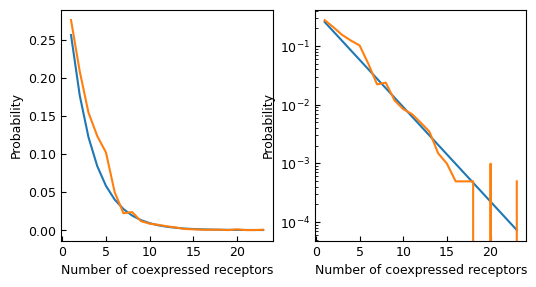

In [4]:
fig,ax = plt.subplots(ncols=2,figsize=(6,3))
ax[0].plot(centers,exp_distrib(centers,popt[0]))
ax[0].plot(centers,Proba_L)

ax[1].plot(centers,exp_distrib(centers,popt[0]))
ax[1].plot(centers,Proba_L)
plt.yscale('log')

for i in range(2):
    ax[i].set_xlabel('Number of coexpressed receptors')
    ax[i].set_ylabel('Probability')

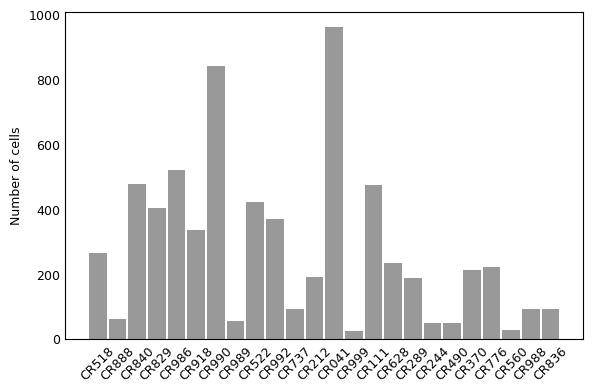

In [10]:
# ================================================
# RELATIVE ABUNDANCE OF EACH RECEPTOR IN POPULATION
# ================================================
CR_counts = A.sum(axis=1)  # per receptor
PCR = CR_counts / np.sum(CR_counts)
plt.figure(figsize=(6, 4))  # ~500x250 px
plt.bar(np.arange(1, nR + 1), CR_counts, width=0.9, color=[0.6, 0.6, 0.6])
plt.ylabel("Number of cells", fontsize=9)
plt.xticks(np.arange(1, nR + 1), CRnames, rotation=45)
ax = plt.gca()
ax.tick_params(length=0, labelsize=9)
plt.tight_layout()

In [6]:
def Pr_combo(combos,PCR):
    res = 1.
    for unit in combos:
        res *= PCR[unit]
    return res

In [7]:
n_types = 24

def P_picking(k):
    Expected = 0.

    for L in range(5):
        E = 0.
        for combos in itertools.combinations(range(n_types), L):
            E+=1 - (1-Pr_combo(combos,PCR))**k
        #E = E*exp_distrib(L,popt[0])
        Expected +=E
    return Expected

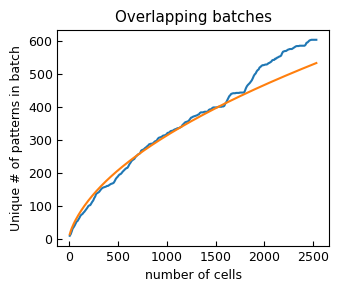

In [ ]:
# ===========================
# BATCH ANALYSIS - MOVING WINDOWS (cumulative windows like MATLAB)
# ===========================
M_cells = A.T
nCells = M_cells.shape[0]
batchEdge = np.arange(10, nCells + 1, 10)  # 10:10:nCells
nBatches = len(batchEdge)
uniquePerBatch = np.zeros(nBatches, dtype=int)
startIdx = 0  # Python 0-based

for b, edge in enumerate(batchEdge):
    stopIdx = min(startIdx + edge, nCells)  # cumulative from start
    if startIdx >= nCells:
        break
    sub = M_cells[startIdx:stopIdx, :]
    # unique rows count
    uniquePerBatch[b] = np.unique(sub, axis=0).shape[0]

plt.figure()
plt.plot(batchEdge, uniquePerBatch)
plt.xlabel("number of cells")
plt.ylabel("Unique # of patterns in batch")
plt.title("Overlapping batches")
    

plt.plot(batchEdge,p_model)

